# 04 — Model Training (From Scratch)

**Mục tiêu:**
- Huấn luyện mô hình Random Forest và SVM tự cài đặt từ đầu (from scratch).
- So sánh hiệu năng với thư viện scikit-learn.

In [6]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from src.models.rf_scratch import RandomForestClassifierScratch
from src.models.svm_scratch import SVMClassifierScratch

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 1. Load Dữ Liệu

In [7]:
TRAIN_PATH = "../data/processed/train.csv"
VAL_PATH = "../data/processed/val.csv"

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")

# Tách features (X) và target (y)
TARGET = "label"
DROP_COLS = [TARGET, "label_name"]

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET]

X_val = val_df.drop(columns=DROP_COLS)
y_val = val_df[TARGET]

# Lấy mapping nhãn thực tế
label_mapping = dict(zip(train_df[TARGET], train_df["label_name"]))
labels_idx = sorted(label_mapping.keys())
class_names = [label_mapping[i] for i in labels_idx]

print("\nFeatures:", X_train.columns.tolist())

Train shape: (1760, 15)
Val shape:   (220, 15)

Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'total_npk', 'ratio_n_p', 'ratio_n_k', 'ratio_p_k', 'temp_humidity', 'log_rainfall']


## 2. Huấn Luyện và Đánh Giá Chi Tiết Từng Mô Hình (Từ Đầu)

In [8]:
# Thiết lập mô hình tự cài đặt
models = {
    "Random Forest (Scratch)": RandomForestClassifierScratch(n_estimators=5, max_depth=10, min_samples_split=2, random_state=42),
    "SVM (Scratch)": SVMClassifierScratch(learning_rate=0.01, lambda_param=0.01, n_iters=1000, random_state=42)
}

results = []
trained_models = {}
predictions = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"🔄 Đang huấn luyện: {name}")
    start_time = time.time()
    
    # Train
    model.fit(X_train, y_train)
    trained_models[name] = model
    train_time = time.time() - start_time
    
    # Predict
    y_pred = model.predict(X_val)
    predictions[name] = y_pred
    
    # Tính toán metrics tổng thể
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Train Time (s)": train_time
    })
    
    print(f"✅ Hoàn tất ({train_time:.4f}s)")
    print(f"Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")


🔄 Đang huấn luyện: Random Forest (Scratch)
✅ Hoàn tất (4.2654s)
Accuracy: 0.9682 | F1-Score: 0.9674

🔄 Đang huấn luyện: SVM (Scratch)
✅ Hoàn tất (1.7028s)
Accuracy: 0.7955 | F1-Score: 0.7769


### 2.1 Trực quan hóa Ma Trận Nhầm Lẫn (Confusion Matrix)

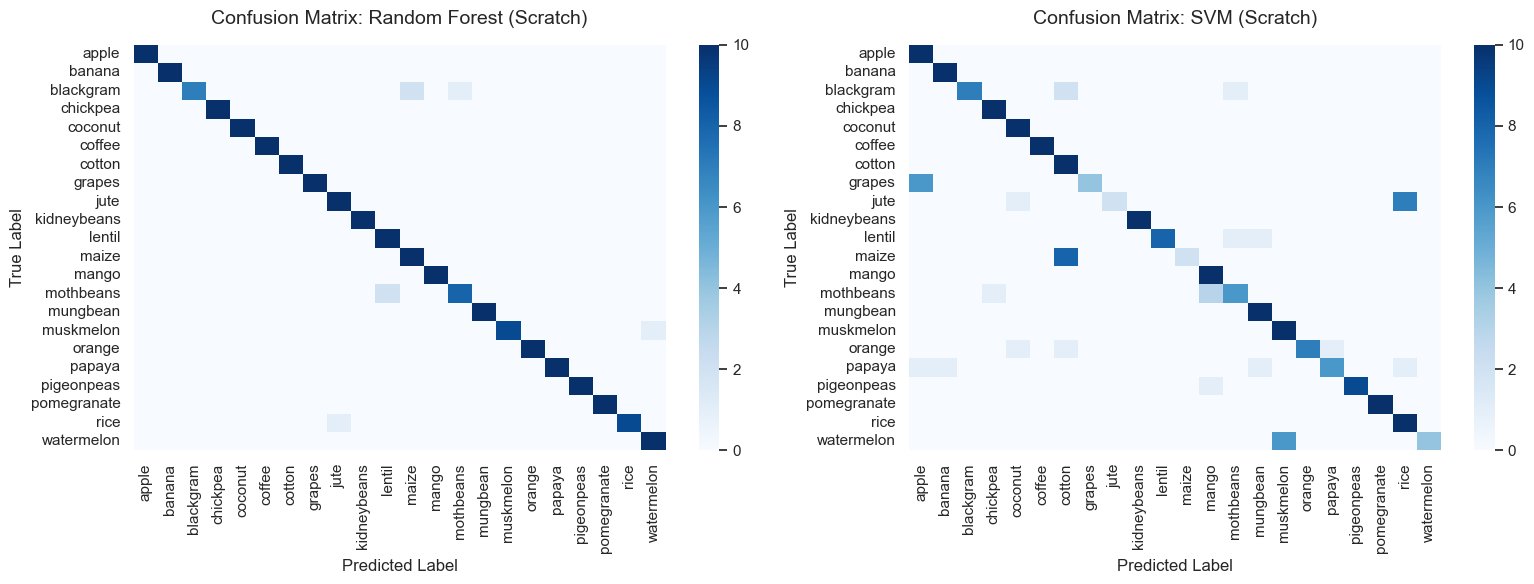

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(y_val, predictions[name])
    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax, xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f"Confusion Matrix: {name}", fontsize=14, pad=15)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 3. Tổng Hợp và Trực Quan Hóa Kết Quả

,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,Random Forest (Scratch),0.9682,0.9715,0.9682,0.9674,4.2654
1,SVM (Scratch),0.7955,0.8660,0.7955,0.7769,1.7028


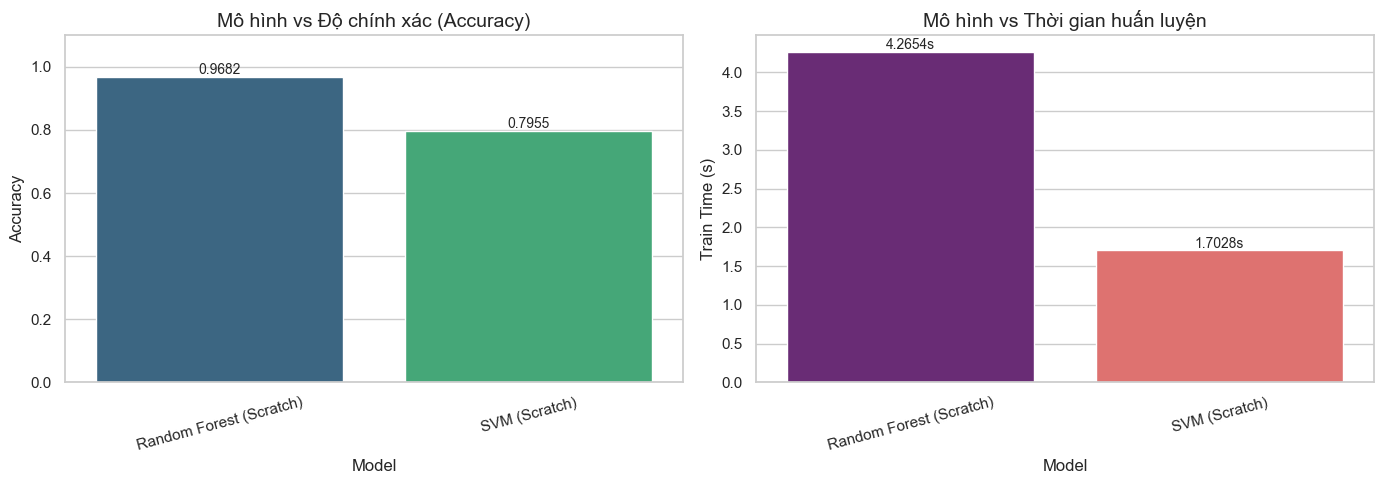

In [10]:
results_df = pd.DataFrame(results)
display(results_df.round(4))

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ Accuracy
sns.barplot(data=results_df, x='Model', y='Accuracy', ax=axes[0], palette='viridis')
axes[0].set_title('Mô hình vs Độ chính xác (Accuracy)', fontsize=14)
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=15)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

# Biểu đồ Thời gian huấn luyện
sns.barplot(data=results_df, x='Model', y='Train Time (s)', ax=axes[1], palette='magma')
axes[1].set_title('Mô hình vs Thời gian huấn luyện', fontsize=14)
axes[1].tick_params(axis='x', rotation=15)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.4f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

## 4. So Sánh Với Baseline (scikit-learn)
Load các mô hình baseline đã lưu và so sánh hiệu năng với các mô hình tự cài đặt.


🔄 Đang đánh giá: Random Forest (Baseline)
✅ Hoàn tất
Accuracy: 0.9955 | F1-Score: 0.9954

🔄 Đang đánh giá: SVM (Baseline)
✅ Hoàn tất
Accuracy: 0.9864 | F1-Score: 0.9863


,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,Random Forest (Scratch),0.9682,0.9715,0.9682,0.9674,4.2654
1,SVM (Scratch),0.7955,0.8660,0.7955,0.7769,1.7028
2,Random Forest (Baseline),0.9955,0.9959,0.9955,0.9954,0.0000
3,SVM (Baseline),0.9864,0.9883,0.9864,0.9863,0.0000


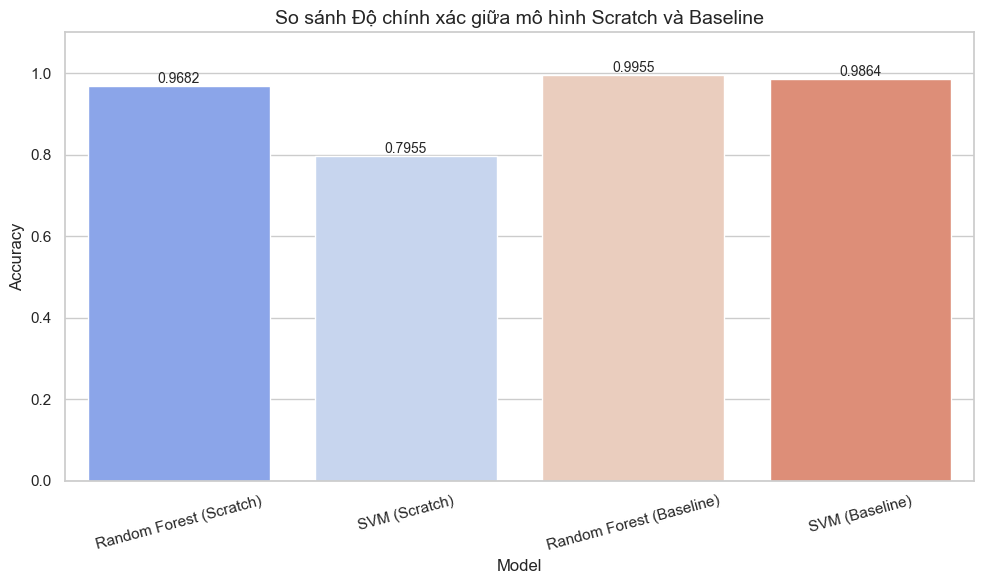

In [11]:
import joblib

# Load baseline models
RF_BASELINE_PATH = '../saved_models/random_forest_baseline.pkl'
SVM_BASELINE_PATH = '../saved_models/svm_baseline.pkl'

rf_baseline = joblib.load(RF_BASELINE_PATH)
svm_baseline = joblib.load(SVM_BASELINE_PATH)

baseline_models = {
    'Random Forest (Baseline)': rf_baseline,
    'SVM (Baseline)': svm_baseline
}

baseline_results = []
baseline_predictions = {}

for name, model in baseline_models.items():
    print(f'\n{'='*50}')
    print(f'🔄 Đang đánh giá: {name}')
    
    # Predict
    y_pred = model.predict(X_val)
    baseline_predictions[name] = y_pred
    
    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')
    
    baseline_results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Train Time (s)': 0.0 # Bỏ qua thời gian train vì load từ file
    })
    
    print(f'✅ Hoàn tất')
    print(f'Accuracy: {acc:.4f} | F1-Score: {f1:.4f}')

# Kết hợp kết quả
all_results_df = pd.concat([results_df, pd.DataFrame(baseline_results)], ignore_index=True)
display(all_results_df.round(4))

# Trực quan hóa so sánh
plt.figure(figsize=(10, 6))
sns.barplot(data=all_results_df, x='Model', y='Accuracy', palette='coolwarm')
plt.title('So sánh Độ chính xác giữa mô hình Scratch và Baseline', fontsize=14)
plt.ylim(0, 1.1)
plt.xticks(rotation=15)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()